In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score

In [23]:
data= pd.read_csv("data.csv")
data


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [24]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [25]:
data.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [26]:
data.drop(['Unnamed: 32', 'id'], axis=1, inplace=True , errors='ignore')
data['diagnosis'] = data['diagnosis'].map({'M': 1, 'B': 0})

In [27]:
data = data.sample(frac=1, random_state=42)

In [28]:
data = data.sample(frac=1, random_state=42)

In [29]:
y = data['diagnosis'].values
x = data.drop(['diagnosis'], axis=1)

In [30]:
y

array([1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0,

In [31]:
outlier_cols = [ 'area_mean','smoothness_mean',  'area_se', 'area_worst', ]

for col in outlier_cols:
    col_mean = data[col].mean()
    col_std = data[col].std()

    final_z_score = []


    for value in data[col]:
        z_score = (value - col_mean) / col_std
        final_z_score.append(float("{:.20f}".format(z_score)))

    data[col] = final_z_score

print(" Standardization Completed ")

 Standardization Completed 


In [32]:
x = (x - x.min()) / (x.max() - x.min())
x

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
280,0.576412,0.571187,0.569484,0.421845,0.445698,0.386234,0.450094,0.480318,0.425253,0.257793,...,0.561722,0.636461,0.544798,0.378195,0.706795,0.346179,0.459585,0.643299,0.333728,0.276532
196,0.321312,0.425431,0.323682,0.188929,0.608197,0.329182,0.324508,0.324354,0.390909,0.396167,...,0.300961,0.586087,0.304746,0.152797,0.677079,0.276421,0.304233,0.574914,0.298640,0.251148
562,0.389938,0.707136,0.411927,0.243224,0.470976,0.580701,0.597470,0.468638,0.539394,0.454086,...,0.341160,0.820096,0.389910,0.179365,0.465760,0.741634,0.934505,0.809622,0.497536,0.563164
397,0.275403,0.262090,0.271301,0.154740,0.251061,0.213392,0.173149,0.202932,0.259596,0.158804,...,0.206688,0.240938,0.200757,0.099735,0.159612,0.149324,0.151837,0.285086,0.083383,0.101600
58,0.287236,0.324653,0.268261,0.162757,0.252505,0.056776,0.001621,0.020711,0.383333,0.106361,...,0.224120,0.272655,0.198366,0.107870,0.204253,0.033588,0.001474,0.038179,0.172285,0.051489
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11,0.416442,0.276632,0.413309,0.270414,0.401462,0.336850,0.233224,0.328330,0.394949,0.228728,...,0.444326,0.406716,0.428756,0.273742,0.451892,0.517711,0.316693,0.621993,0.438991,0.326381
163,0.253632,0.423064,0.249188,0.136161,0.438476,0.251886,0.125820,0.140258,0.247980,0.371735,...,0.200996,0.444030,0.184023,0.090395,0.488873,0.200357,0.134824,0.281581,0.138577,0.234685
496,0.268304,0.286101,0.268813,0.145111,0.496253,0.349733,0.187840,0.252187,0.293434,0.391323,...,0.229456,0.269989,0.223517,0.110229,0.542363,0.346276,0.286102,0.483505,0.328208,0.316542
256,0.594870,0.644572,0.620621,0.451113,0.360838,0.573339,0.417994,0.568588,0.420707,0.260320,...,0.609036,0.646322,0.638428,0.427841,0.375949,0.490545,0.339537,0.667010,0.246994,0.298177


In [33]:
x_train, x_remaining, y_train, y_remaining = train_test_split(
    x, y, test_size=0.70, random_state=42
)


x_test1, x_test2, y_test1, y_test2 = train_test_split(
    x_remaining, y_remaining, test_size=0.5, random_state=42
)

print("Success: Data was standardized first, then split.")
print("Train shape:", x_train.shape)
print("Test1 shape:", x_test1.shape)
print("Test2 shape:", x_test2.shape)

Success: Data was standardized first, then split.
Train shape: (170, 30)
Test1 shape: (199, 30)
Test2 shape: (200, 30)


In [34]:

knn = KNeighborsClassifier(n_neighbors=4, weights='distance')


knn.fit(x_train, y_train)

print("Model Trained Successfully.")

Model Trained Successfully.


Training Accuracy: 100.00%


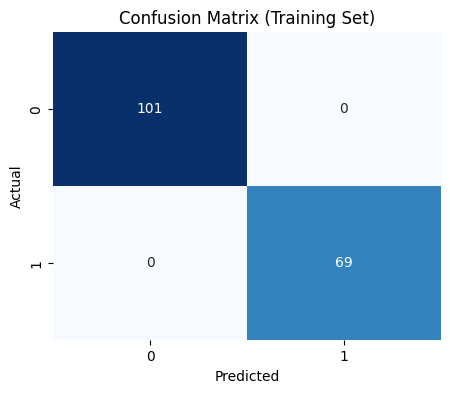

In [35]:

y_pred_train = knn.predict(x_train)


acc_train = accuracy_score(y_train, y_pred_train)
cm_train = confusion_matrix(y_train, y_pred_train)

print(f"Training Accuracy: {acc_train*100:.2f}%")


plt.figure(figsize=(5, 4))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Training Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

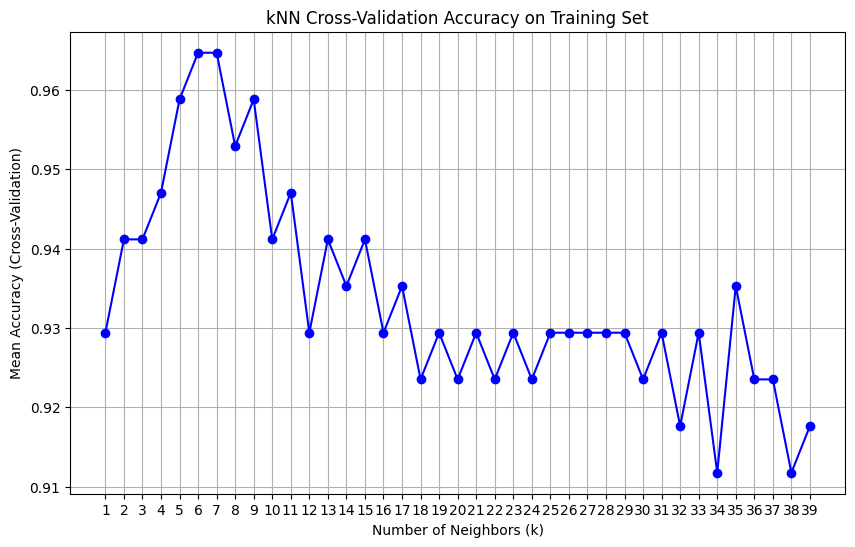

In [36]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score, KFold
from sklearn.neighbors import KNeighborsClassifier


k_values = range(1, 40)
mean_accuracies = []

kf = KFold(n_splits=10, shuffle=True, random_state=42)


for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')


    scores = cross_val_score(knn, x_train, y_train, cv=kf, scoring='accuracy')

    mean_acc = np.mean(scores)
    mean_accuracies.append(mean_acc)


plt.figure(figsize=(10,6))
plt.plot(k_values, mean_accuracies, marker='o', linestyle='-', color='b')
plt.title('kNN Cross-Validation Accuracy on Training Set')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean Accuracy (Cross-Validation)')
plt.xticks(k_values)
plt.grid(True)
plt.show()



In [37]:

knn = KNeighborsClassifier(n_neighbors=6, weights='distance')


knn.fit(x_train, y_train)

print("Model Trained Successfully.")

Model Trained Successfully.


Training Accuracy: 100.00%


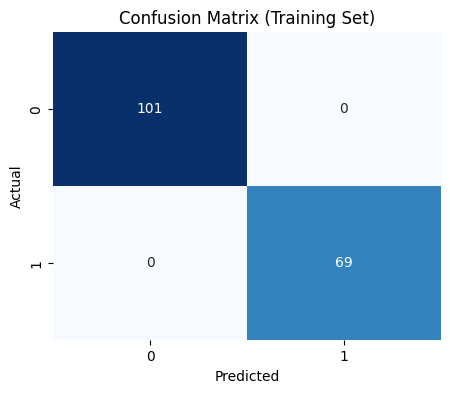

In [38]:

y_pred_train = knn.predict(x_train)


acc_train = accuracy_score(y_train, y_pred_train)
cm_train = confusion_matrix(y_train, y_pred_train)

print(f"Training Accuracy: {acc_train*100:.2f}%")


plt.figure(figsize=(5, 4))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Training Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Test 1

--- Test 1 Results ---
Accuracy: 95.48%


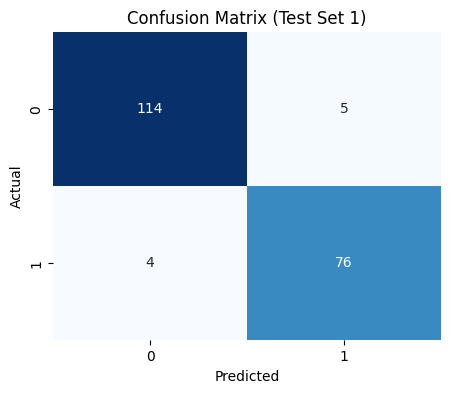

In [39]:

y_pred_test1 = knn.predict(x_test1)


acc_test1 = accuracy_score(y_test1, y_pred_test1)
rec_test1 = recall_score(y_test1, y_pred_test1)
cm_test1 = confusion_matrix(y_test1, y_pred_test1)

print("--- Test 1 Results ---")
print(f"Accuracy: {acc_test1*100:.2f}%")



plt.figure(figsize=(5, 4))
sns.heatmap(cm_test1, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Test Set 1)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# on best k

In [40]:

best_k = 6

knn_best = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn_best.fit(x_train, y_train)


y_test1_flat = y_test1
y_pred_test1= knn_best.predict(x_test1)


test1_accuracy = 100 - np.mean(np.abs(y_pred_test1 - y_test1_flat)) * 100
print(f"Test1 accuracy with best k={best_k}: {test1_accuracy:.2f}%")

Test1 accuracy with best k=6: 97.49%


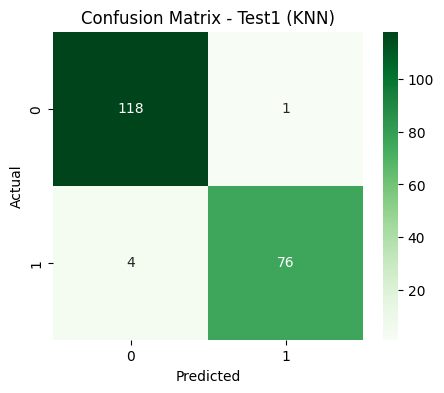

In [41]:



cm_test1 = confusion_matrix(y_test1, y_pred_test1)


plt.figure(figsize=(5,4))
sns.heatmap(cm_test1, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Test1 (KNN)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [42]:
from sklearn.metrics import confusion_matrix


cm_test1 = confusion_matrix(y_test1, y_pred_test1)

TP = cm_test1[1, 1]
FP = cm_test1[0, 1]
TN = cm_test1[0, 0]
FN = cm_test1[1, 0]

precision_test1 = TP / (TP + FP)
recall_test1 = TP / (TP + FN)
specificity_test1 = TN / (TN + FP)
accuracy_test1 = (TP + TN) / (TP + TN + FP + FN)
F1_test1 = 2 * (precision_test1 * recall_test1) / (precision_test1 + recall_test1)

print("Metrics for Test1 Set (KNN):")
print(f"Accuracy: {accuracy_test1:.2f}")
print(f"Precision: {precision_test1:.2f}")
print(f"Recall (Sensitivity): {recall_test1:.2f}")
print(f"Specificity: {specificity_test1:.2f}")
print(f"F1 score: {F1_test1:.2f}")


Metrics for Test1 Set (KNN):
Accuracy: 0.97
Precision: 0.99
Recall (Sensitivity): 0.95
Specificity: 0.99
F1 score: 0.97


# Test 2

--- Test 2 Results ---
Accuracy: 97.00%


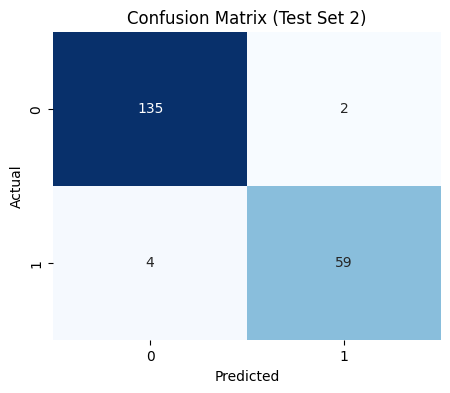

In [43]:

y_pred_test2 = knn.predict(x_test2)


acc_test2 = accuracy_score(y_test2, y_pred_test2)
rec_test2 = recall_score(y_test2, y_pred_test2)
cm_test2 = confusion_matrix(y_test2, y_pred_test2)

print("--- Test 2 Results ---")
print(f"Accuracy: {acc_test2*100:.2f}%")


# Plot
plt.figure(figsize=(5, 4))
sns.heatmap(cm_test2, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Test Set 2)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# on best k

In [44]:

best_k = 6


knn_best = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn_best.fit(x_train, y_train)


y_pred_test2 = knn_best.predict(x_test2)


test2_accuracy_knn = 100 - np.mean(np.abs(y_pred_test2 - y_test2)) * 100
print(f"Test2 accuracy with best k={best_k}: {test2_accuracy_knn}%")

Test2 accuracy with best k=6: 98.0%


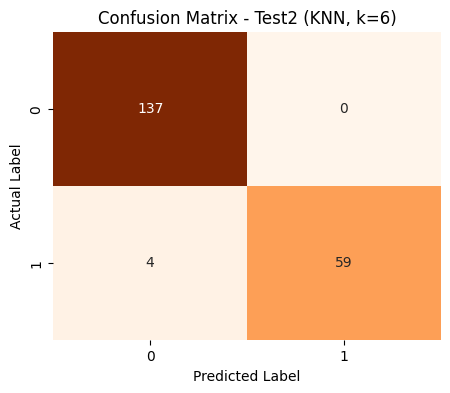

In [46]:
cm_test2 = confusion_matrix(y_test2, y_pred_test2)

plt.figure(figsize=(5,4))
sns.heatmap(cm_test2, annot=True, fmt="d", cmap="Oranges", cbar=False)
plt.title(f"Confusion Matrix - Test2 (KNN, k={best_k})")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [48]:
from sklearn.metrics import confusion_matrix


y_pred_test2 = knn_best.predict(x_test2)


cm_test2 = confusion_matrix(y_test2, y_pred_test2)

TP = cm_test2[1, 1]
FP = cm_test2[0, 1]
TN = cm_test2[0, 0]
FN = cm_test2[1, 0]

precision_test2 = TP / (TP + FP)
recall_test2 = TP / (TP + FN)
specificity_test2 = TN / (TN + FP)
accuracy_test2 = (TP + TN) / (TP + TN + FP + FN)
F1_test2 = 2 * (precision_test2 * recall_test2) / (precision_test2 + recall_test2)

print(f"Metrics for Test2 Set (KNN with k={best_k}):")
print(f"Accuracy: {accuracy_test2:.2f}")
print(f"Precision: {precision_test2:.2f}")
print(f"Recall (Sensitivity): {recall_test2:.2f}")
print(f"Specificity: {specificity_test2:.2f}")
print(f"F1 score: {F1_test2:.2f}")

Metrics for Test2 Set (KNN with k=6):
Accuracy: 0.98
Precision: 1.00
Recall (Sensitivity): 0.94
Specificity: 1.00
F1 score: 0.97
